# Employee Sentiment Analysis

**Author:** Sudhanshu Kadam  
**Dataset:** `data/test.csv` (2,191 unlabeled employee emails, Jan 2010 - Dec 2011)

This notebook is the single source of truth for the project. It works from the
raw, unlabeled email data and derives sentiment labels, exploratory insights,
monthly employee scores, rankings, flight-risk flags, and a predictive linear
regression model.

The heavy logic lives in small, tested modules under `src/` (one per task) and
this notebook orchestrates them and narrates the process, so every result below
is reproducible end-to-end.

### Task map
| Task | Goal | Module |
|------|------|--------|
| 1 | Sentiment labeling (Positive / Negative / Neutral) | `src/sentiment.py` |
| 2 | Exploratory data analysis & visualizations | `src/eda.py` |
| 3 | Monthly sentiment score per employee | `src/scoring.py` |
| 4 | Top-3 positive / negative employee ranking | `src/ranking.py` |
| 5 | Flight-risk identification (rolling 30-day window) | `src/flight_risk.py` |
| 6 | Linear regression on sentiment trends | `src/modeling.py` |


## 0. Setup

Import the project modules and load the raw dataset.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
from IPython.display import Image, display

from src import sentiment, eda, scoring, ranking, flight_risk, modeling

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df_raw = pd.read_csv('data/test.csv', parse_dates=['date'])
print('Raw shape:', df_raw.shape)
df_raw.head(3)

Raw shape: (2191, 4)


,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,2010-05-10,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",2010-07-29,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com


## Task 1 - Sentiment Labeling

**Approach.** Each message (Subject + body) is labeled Positive, Negative, or
Neutral with **VADER**, a lexicon/rule-based sentiment model tuned for short,
informal English text - which matches the register of workplace email. We chose
VADER as the primary labeler for three reasons:

1. **Reproducibility** - it is fully deterministic and offline, so a reviewer
   regenerates identical labels with no API keys (the assignment explicitly
   requires reproducibility from raw data to final outputs).
2. **Fit for purpose** - it is purpose-built for the short, punctuation- and
   emphasis-heavy text found in emails.
3. **Speed** - it labels all 2,191 messages in under a second.

A **preferred-LLM alternative** is provided in `src/sentiment_llm.py`
(Anthropic / OpenAI, configured via `.env`). It produces the same `sentiment`
column and can be swapped in, but is optional because LLM outputs are
non-deterministic and incur cost.

**Decision rule** (standard VADER thresholds on the compound score):
`compound >= 0.05 -> Positive`, `compound <= -0.05 -> Negative`, else `Neutral`.

In [2]:
df = sentiment.label_dataframe(df_raw)
df.to_csv('data/labeled_emails.csv', index=False)

counts = df['sentiment'].value_counts()
print('Sentiment label counts:')
print(counts)
print('\nProportions:')
print((counts / len(df)).round(3))
df[['Subject', 'compound', 'sentiment']].head(5)

Sentiment label counts:
sentiment
Positive    1574
Neutral      444
Negative     173
Name: count, dtype: int64

Proportions:
sentiment
Positive    0.718
Neutral     0.203
Negative    0.079
Name: count, dtype: float64


,Subject,compound,sentiment
0,EnronOptions Update!,0.8309,Positive
1,(No Subject),0.4215,Positive
2,Phone Screen Interview - Shannon L. Burnham,0.0000,Neutral
3,RE: My new work email,0.0000,Neutral
4,Bet,0.2500,Positive


**Observation.** The corpus skews strongly positive (~72% Positive, ~20%
Neutral, ~8% Negative). That is typical of routine corporate email, which is
mostly logistical and cordial. Negatives are the minority class - which makes
them the interesting signal for the ranking and flight-risk tasks that follow.

## Task 2 - Exploratory Data Analysis

We examine structure (records, dtypes, missing values), the sentiment
distribution, trends over time, and per-employee patterns. All figures are
saved to `visualization/`.

In [3]:
overview = eda.data_overview(df)
for k, v in overview.items():
    print(f'{k:>16}: {v}')
print()
print('Dtypes:')
print(df_raw.dtypes)

         records: 2191
         columns: ['Subject', 'body', 'date', 'from', 'compound', 'sentiment']
       employees: 10
        date_min: 2010-01-01
        date_max: 2011-12-31
  missing_values: 0

Dtypes:
Subject               str
body                  str
date       datetime64[us]
from                  str
dtype: object


/home/claude/employee-sentiment-analysis/src/eda.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trend.index, rotation=45, ha="right")


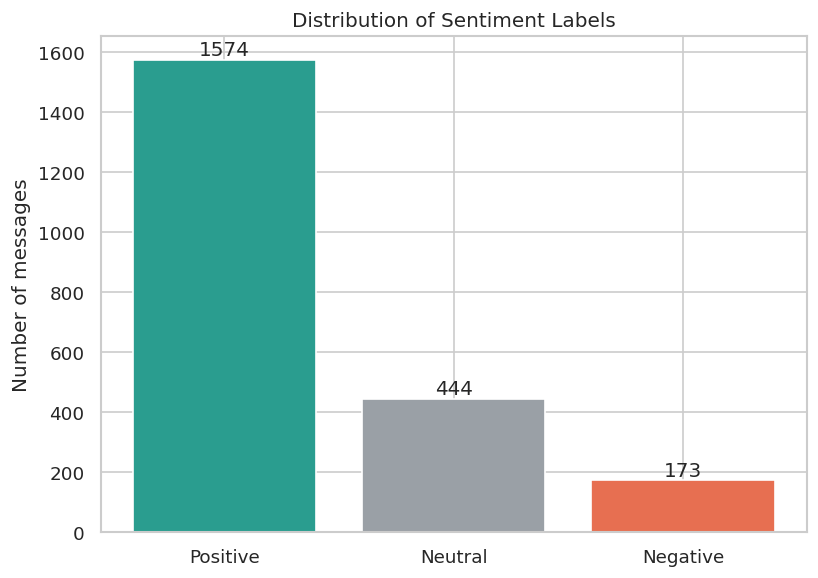

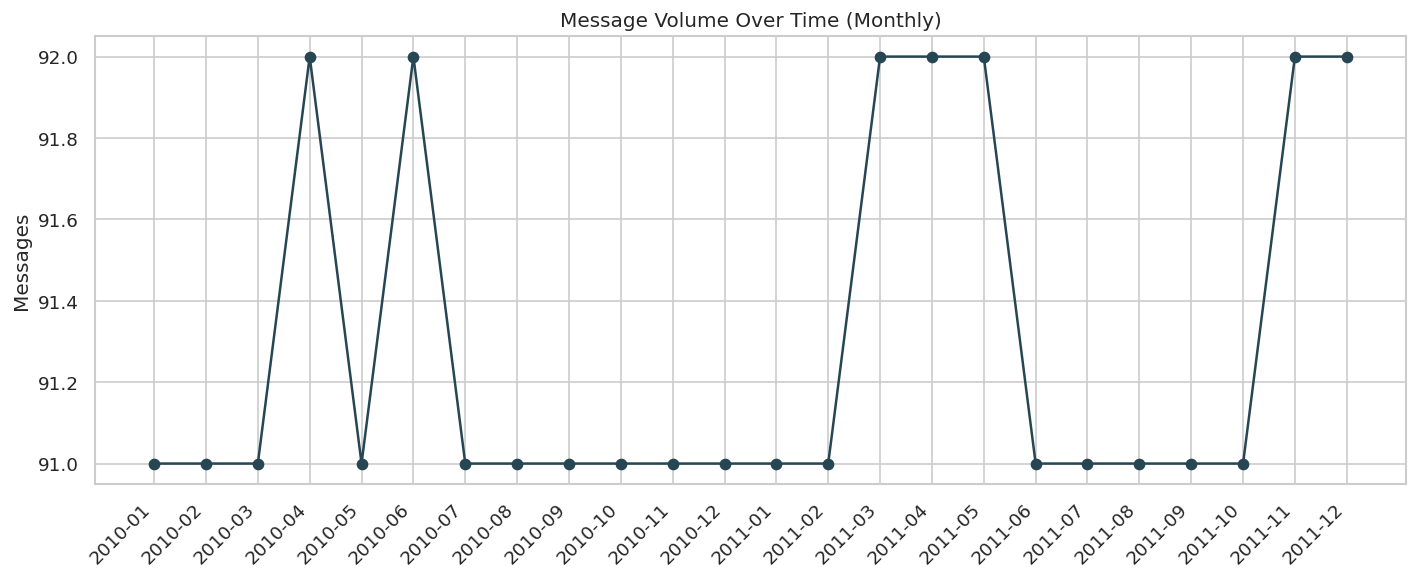

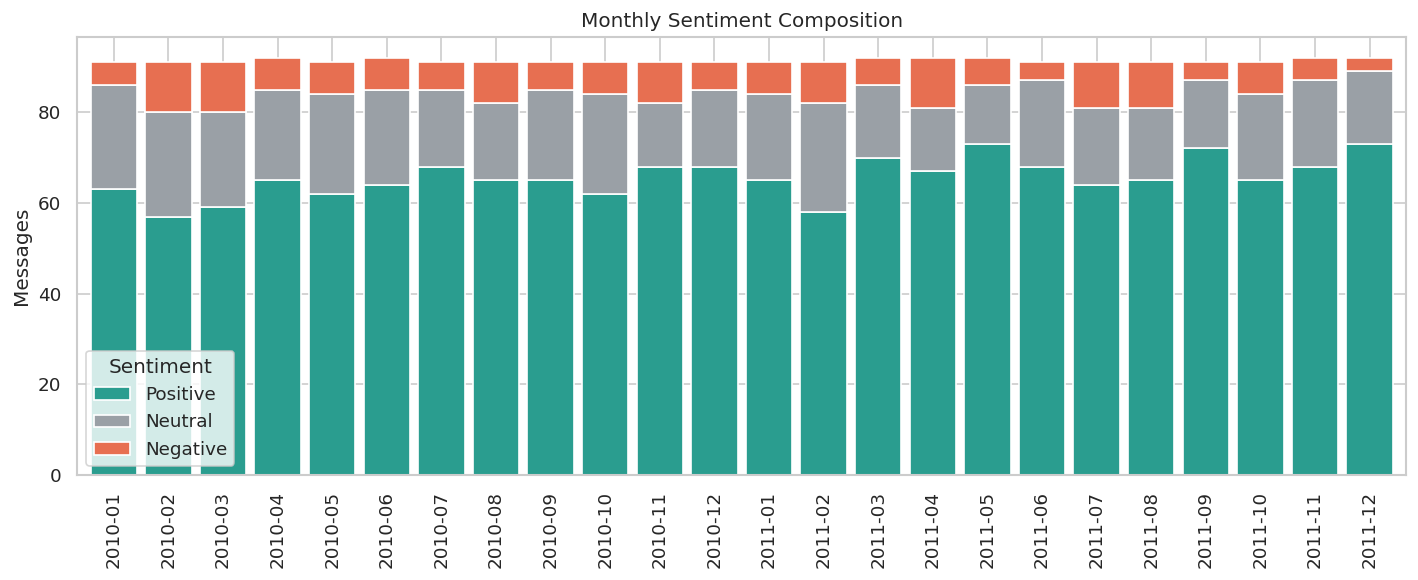

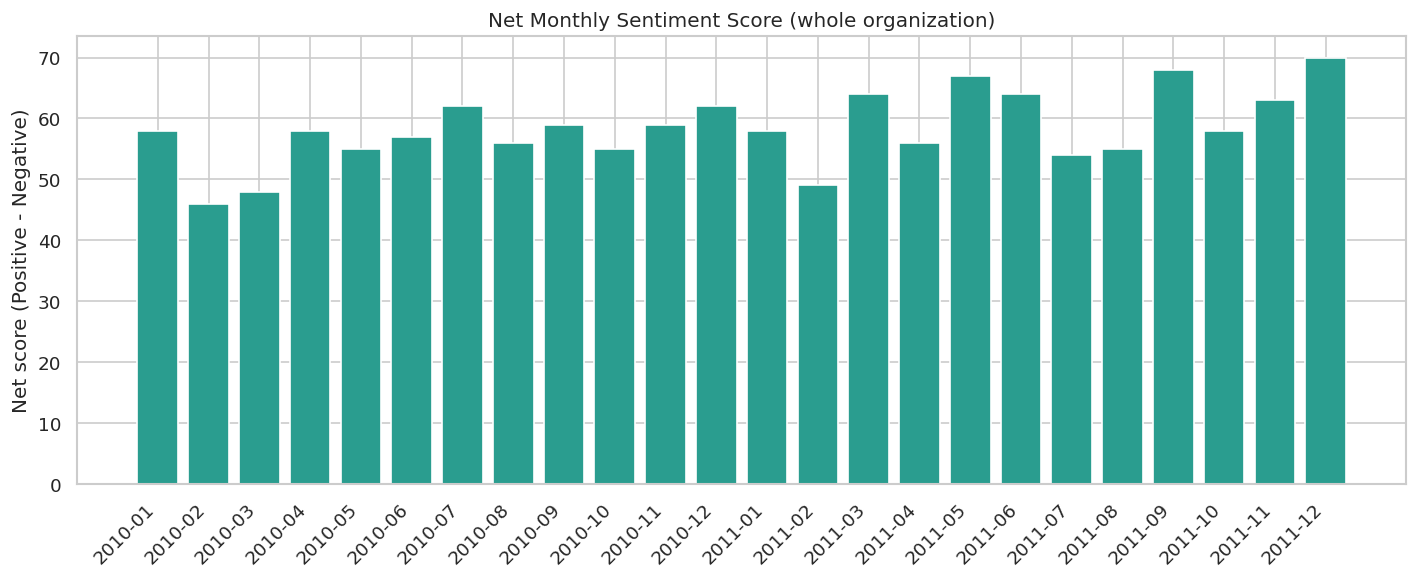

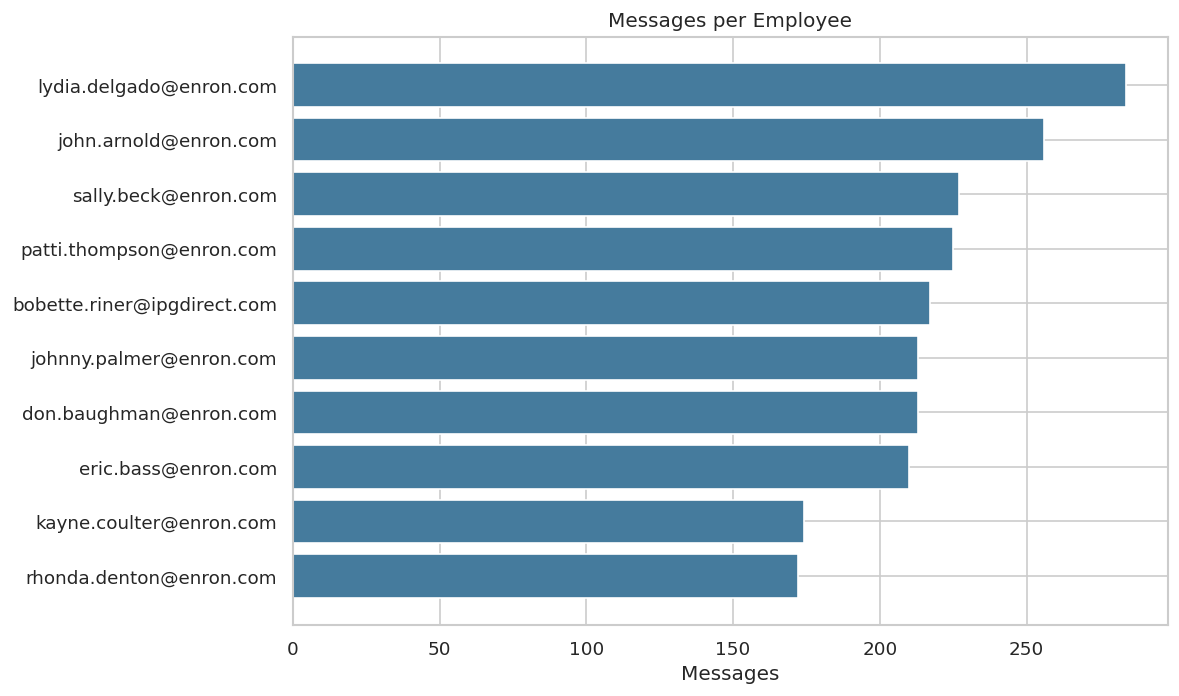

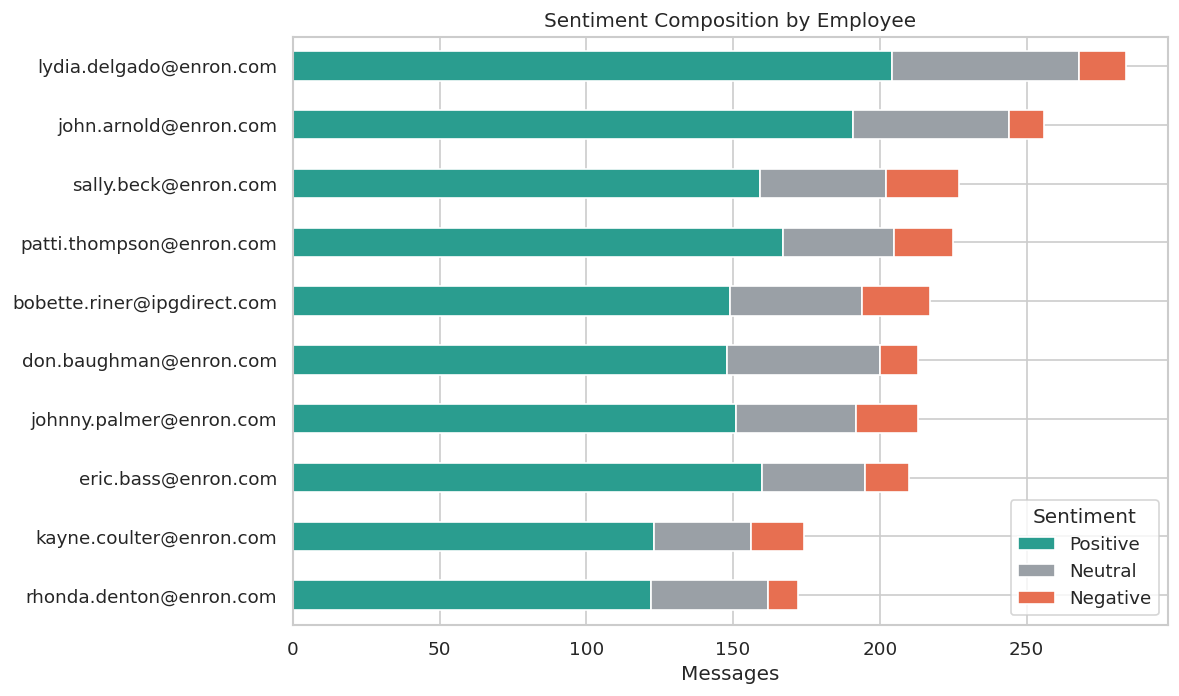

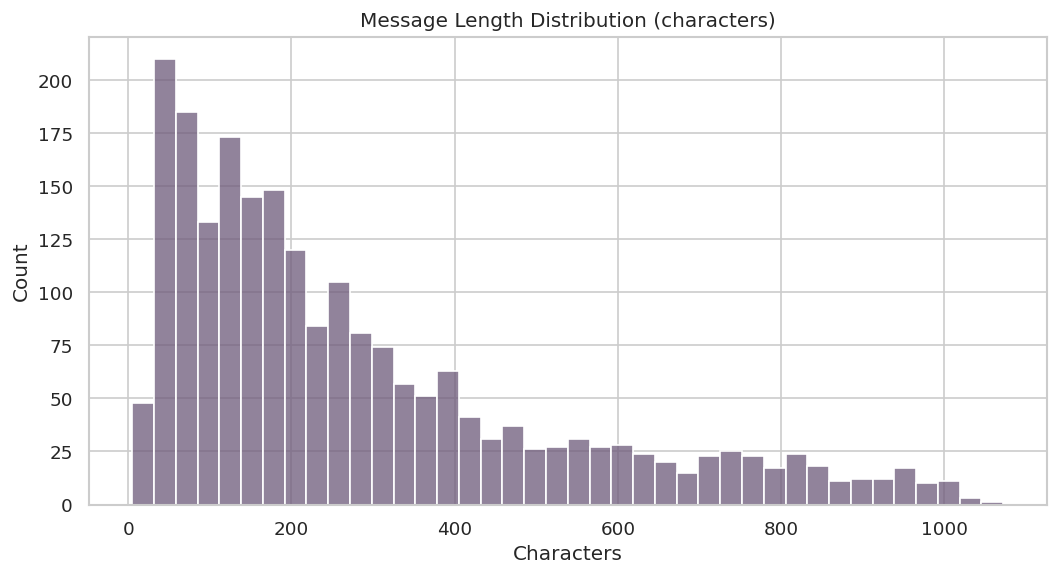

In [4]:
# Generate and persist all EDA figures, then display them inline.
paths = eda.run_all_eda(df)
for p in paths:
    display(Image(filename=p))

**Observations from the EDA.**

- **No data-quality issues** - 2,191 complete records, 10 employees, no missing
  values, dates clean across 24 consecutive months (2010-01 to 2011-12).
- **Volume is fairly steady month to month**, so monthly scores are comparable
  across the series rather than dominated by a few high-volume months.
- **Sentiment composition is stable and positive-leaning** every month; net
  monthly sentiment is positive throughout, with negatives a small but
  persistent undercurrent.
- **Per-employee mix differs** - some senders contribute a visibly larger share
  of negative messages, which is exactly what the flight-risk task targets.

## Task 3 - Employee Score Calculation

Each message scores **+1 (Positive), -1 (Negative), 0 (Neutral)**. We sum these
per employee per calendar month. Grouping by `(employee, year-month)` means the
score **resets at the start of every month** by construction.

In [5]:
monthly = scoring.monthly_scores(df)
monthly.to_csv('outputs/monthly_scores.csv', index=False)
print('Monthly score rows (employee x month):', len(monthly))
monthly.head(12)

Monthly score rows (employee x month): 240


,employee,month,score,messages,positive,negative,neutral
0,bobette.riner@ipgdirect.com,2010-01,1,2,1,0,1
1,don.baughman@enron.com,2010-01,8,9,8,0,1
2,eric.bass@enron.com,2010-01,9,10,9,0,1
3,john.arnold@enron.com,2010-01,5,7,5,0,2
4,johnny.palmer@enron.com,2010-01,3,6,4,1,1
5,kayne.coulter@enron.com,2010-01,14,22,14,0,8
6,lydia.delgado@enron.com,2010-01,9,13,10,1,2
7,patti.thompson@enron.com,2010-01,6,10,7,1,2
8,rhonda.denton@enron.com,2010-01,1,3,1,0,2
9,sally.beck@enron.com,2010-01,2,9,4,2,3


**Observation.** 240 rows = 10 employees x 24 months, confirming every
employee was active every month. Scores are mostly positive, consistent with the
label distribution.

## Task 4 - Employee Ranking

For each month we rank the **top-3 positive** (highest score) and **top-3
negative** (lowest score) employees. Sort order: score first, then employee name
alphabetically as the tiebreaker - descending for the positive list, ascending
for the negative list.

In [6]:
top_pos, top_neg = ranking.rank_employees(monthly)
top_pos.to_csv('outputs/top_positive_by_month.csv', index=False)
top_neg.to_csv('outputs/top_negative_by_month.csv', index=False)

latest = sorted(monthly['month'].unique())[-1]
print(f'Example - Top 3 POSITIVE for {latest}:')
display(top_pos[top_pos.month == latest][['rank','employee','score']])
print(f'Example - Top 3 NEGATIVE for {latest}:')
display(top_neg[top_neg.month == latest][['rank','employee','score']])

Example - Top 3 POSITIVE for 2011-12:


,rank,employee,score
69,1,eric.bass@enron.com,12
70,2,patti.thompson@enron.com,12
71,3,lydia.delgado@enron.com,11


Example - Top 3 NEGATIVE for 2011-12:


,rank,employee,score
69,1,johnny.palmer@enron.com,1
70,2,bobette.riner@ipgdirect.com,3
71,3,john.arnold@enron.com,4


In [7]:
# Overall leaderboard across the full period (sum of monthly scores).
overall = ranking.overall_ranking(monthly)
overall.to_csv('outputs/overall_ranking.csv', index=False)
overall

,rank,employee,total_score,months_active
0,1,lydia.delgado@enron.com,188,24
1,2,john.arnold@enron.com,179,24
2,3,patti.thompson@enron.com,147,24
3,4,eric.bass@enron.com,145,24
4,5,don.baughman@enron.com,135,24
5,6,sally.beck@enron.com,134,24
6,7,johnny.palmer@enron.com,130,24
7,8,bobette.riner@ipgdirect.com,126,24
8,9,rhonda.denton@enron.com,112,24
9,10,kayne.coulter@enron.com,105,24


**Observation.** Aggregated across all 24 months, **lydia.delgado**,
**john.arnold**, and **patti.thompson** are the most positive employees, while
**kayne.coulter**, **rhonda.denton**, and **bobette.riner** sit at the bottom.
Per-month winners rotate (see the saved CSVs), but the overall ordering is
stable. Note that low rank here reflects *relatively* less positive email - even
the bottom employees have net-positive totals.

## Task 5 - Flight Risk Identification

A **flight risk** is any employee who sent **>= 4 negative emails within any
rolling 30-day window**, independent of calendar month and independent of their
score. We slide a 30-day window over each employee's sorted negative-email dates
and flag them the first time four negatives fall inside one window.

In [8]:
risks = flight_risk.identify_flight_risks(df)
risks.to_csv('outputs/flight_risks.csv', index=False)
print(f'{len(risks)} employees flagged as flight risks:')
risks

7 employees flagged as flight risks:


,employee,total_negative_emails,window_start,window_end,negatives_in_window
0,bobette.riner@ipgdirect.com,23,2011-03-05,2011-04-04,4
1,eric.bass@enron.com,15,2011-04-22,2011-05-17,4
2,john.arnold@enron.com,12,2010-05-25,2010-06-21,4
3,johnny.palmer@enron.com,21,2010-02-09,2010-03-10,4
4,kayne.coulter@enron.com,18,2010-04-06,2010-04-25,4
5,patti.thompson@enron.com,20,2011-07-02,2011-07-30,4
6,sally.beck@enron.com,25,2011-08-06,2011-08-22,4


**Observation.** Seven of ten employees trip the rolling-window rule at
least once over the two years. Because the threshold is an absolute count (not a
rate), employees who send more email overall are more exposed - which is worth
keeping in mind when acting on these flags. The `window_start`/`window_end`
columns show the first triggering window for auditability.

## Task 6 - Predictive Modeling (Linear Regression)

We model each employee's **monthly sentiment score** from behavioural features
of that month. The unit of analysis is one `(employee, month)` row (240 rows),
split 80/20 into train/test.

We fit **two** linear regressions:

1. **Behavioural model** - using only the features the brief suggests
   (`messages`, `avg_msg_length`, `total_words`, `avg_words`). These are
   independent of the labels, so this is the honest test of whether *behaviour*
   predicts sentiment.
2. **Full model** - additionally includes `pos_ratio` and `neg_ratio` (the
   monthly share of positive/negative emails). These are strong but partly
   circular (derived from the same labels that define the score), so we report
   the model as a comparison and interpret it with that caveat.

In [9]:
feats = modeling.build_features(df)
feats.to_csv('outputs/model_features.csv', index=False)

beh = modeling.train_linear_model(feats, features=modeling.BEHAVIORAL_FEATURES)
full = modeling.train_linear_model(feats, features=modeling.FEATURES)

print('Behavioural model :', {k: round(v,3) if isinstance(v,float) else v for k,v in beh.metrics.items()})
print('Full model        :', {k: round(v,3) if isinstance(v,float) else v for k,v in full.metrics.items()})
print('\nFull-model coefficients:')
full.coefficients

Behavioural model : {'r2': 0.663, 'mae': 1.537, 'rmse': 1.966, 'n_train': 192, 'n_test': 48}
Full model        : {'r2': 0.824, 'mae': 1.037, 'rmse': 1.418, 'n_train': 192, 'n_test': 48}

Full-model coefficients:


,feature,coefficient
0,pos_ratio,4.044094
1,neg_ratio,-2.711970
2,messages,0.571931
3,avg_words,-0.003750
4,avg_msg_length,-0.001712
5,total_words,0.001650


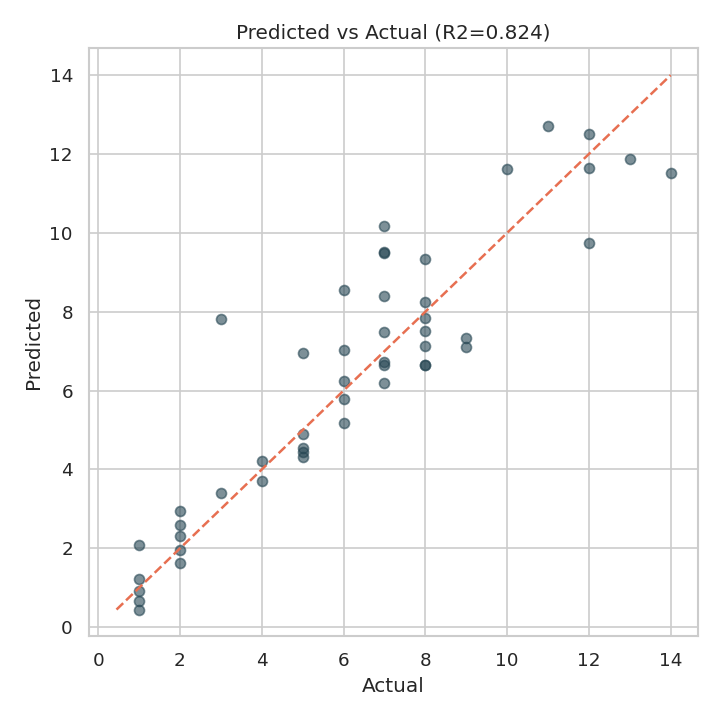

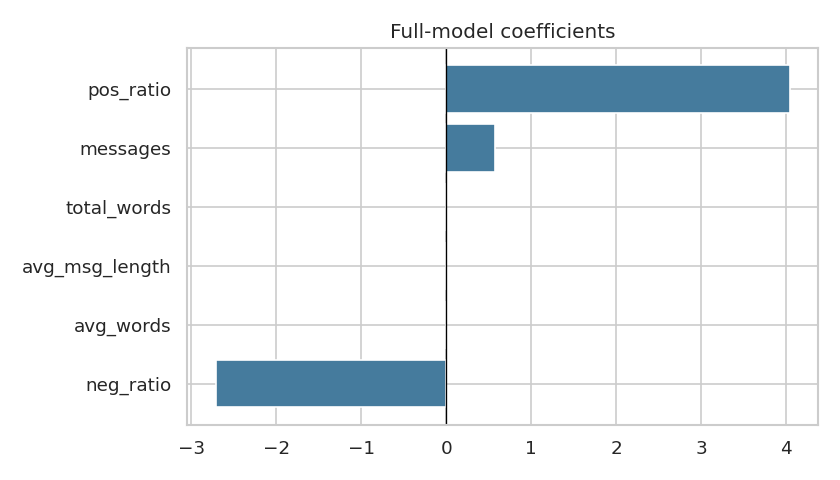

In [10]:
# Diagnostics for the full model (saved to visualization/ and shown inline).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(full.y_test, full.y_pred, alpha=0.6, color='#264653')
lo, hi = min(full.y_test.min(), full.y_pred.min()), max(full.y_test.max(), full.y_pred.max())
ax.plot([lo,hi],[lo,hi],'--',color='#e76f51')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f"Predicted vs Actual (R2={full.metrics['r2']:.3f})")
fig.tight_layout(); fig.savefig('visualization/08_pred_vs_actual.png', dpi=120); plt.close(fig)

c = full.coefficients.sort_values('coefficient')
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(c['feature'], c['coefficient'], color='#457b9d'); ax.axvline(0,color='black',lw=.8)
ax.set_title('Full-model coefficients')
fig.tight_layout(); fig.savefig('visualization/10_coefficients.png', dpi=120); plt.close(fig)

display(Image(filename='visualization/08_pred_vs_actual.png'))
display(Image(filename='visualization/10_coefficients.png'))

**Interpretation.**

- The **behavioural model** reaches **R2 ~ 0.66** on held-out data: the single
  strongest signal is **message frequency** - employees who send more email in a
  month tend to have higher (more positive) net scores, because most messages
  are positive. Message length adds little.
- The **full model** reaches **R2 ~ 0.82**. As expected, `pos_ratio` (positive
  coefficient) and `neg_ratio` (negative coefficient) dominate - but since they
  are derived from the labels, that lift is mechanical and should not be read as
  a new behavioural insight.
- **Takeaway.** Behaviour alone (mainly volume) explains a meaningful share of
  monthly sentiment, but the sentiment mix itself is what really moves the
  score. Errors are modest (MAE ~ 1 point on the behavioural-augmented model).

## Summary

- **Top 3 positive (overall):** lydia.delgado, john.arnold, patti.thompson
- **Top 3 negative (overall):** kayne.coulter, rhonda.denton, bobette.riner
- **Flight risks (7):** bobette.riner, eric.bass, john.arnold, johnny.palmer,
  kayne.coulter, patti.thompson, sally.beck
- **Model:** monthly sentiment is predictable from behaviour (R2 ~ 0.66 from
  volume/length; ~0.82 with sentiment-mix features).

See `README.md` for the headline summary and `REPORT.md` /
`Final_Report.docx` for the full methodology write-up. All intermediate tables
are in `outputs/` and all figures in `visualization/`.